## 1. Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from langdetect import detect, LangDetectException

## 2. Load data

In [2]:
# Load data
INPUT_FILE = 'reviews_output.csv'
OUTPUT_FILE = 'reviews_cleaned.csv'

df = pd.read_csv(INPUT_FILE)
print(f'Total reviews: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Total reviews: 41344
Columns: ['review_id', 'hotel_id', 'review_text', 'rating']


,review_id,hotel_id,review_text,rating
0,1065527135,1001042,Sansan thật tuyệt vời và đó là nơi tôi luôn ch...,10.0
1,1042633845,1001042,Địa điểm tại đây khá thuận tiện cho khách du l...,8.0
2,970993281,1001042,Tôi rất thích khách sạn này. Nó nằm ở một con ...,10.0
3,889877242,1001042,trời ơi đi du lịch 1 mình từ lâu nhưng bà lễ t...,10.0
4,886199161,1001042,Tôi đã nhận được một số ưu đãi từ Agoda và có ...,10.0
5,911537767,1001042,Tôi đã ở nhiều khách sạn trong khu vực và khác...,9.0
6,1044862649,1001042,"Khách sạn sạch sẽ, thoáng mát, nhân viên nhiệt...",9.0
7,838535049,1001042,"Đặt kỳ vọng trước khi đặt phòng, đây là một kh...",9.0
8,931256741,1001042,Tài sản thì tuyệt vời trên tất cả các phương d...,10.0
9,1071090374,1001042,"Gần bãi biển, xung quanh chỗ ở có nhiều nhà hà...",8.0


## 3. EDA

In [3]:
print('=== Statistics ===')
print(f'Total reviews: {len(df):,}')
print(f'The number of unique hotels: {df["hotel_id"].nunique():,}')
print(f'Review deduplication ID: {df["review_id"].nunique():,} unique reviews')
print(f'Review have text empty: {df["review_text"].isna().sum():,}')
print(f'Review rating null: {df["rating"].isna().sum():,}')
print()

# Text length stats
df['text_len'] = df['review_text'].astype(str).str.len()
print('=== Length of reviews (characters) ===')
print(df['text_len'].describe())
print()

# Rating distribution
print('=== Rating distribution ===')
print(df['rating'].value_counts().sort_index())

=== Statistics ===
Total reviews: 41,344
The number of unique hotels: 392
Review deduplication ID: 41,344 unique reviews
Review have text empty: 5
Review rating null: 0

=== Length of reviews (characters) ===
count    41344.000000
mean       210.535096
std        257.494391
min          1.000000
25%         60.000000
50%        134.000000
75%        265.000000
max       5634.000000
Name: text_len, dtype: float64

=== Rating distribution ===
rating
2.0      1272
3.0       763
4.0      1423
5.0      1248
6.0      2746
7.0      2618
8.0      6791
9.0      7453
10.0    17030
Name: count, dtype: int64


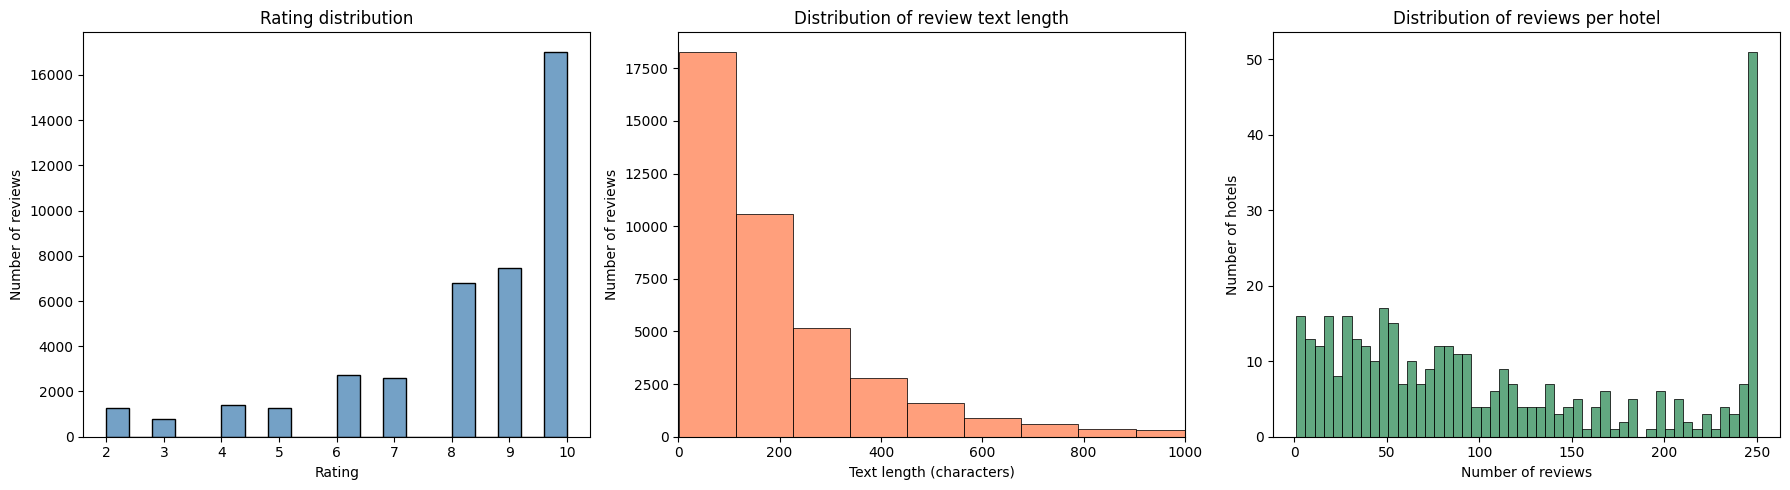

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating distribution
sns.histplot(df['rating'].dropna(), bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of reviews')

# Text length distribution
sns.histplot(df['text_len'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Distribution of review text length')
axes[1].set_xlabel('Text length (characters)')
axes[1].set_ylabel('Number of reviews')
axes[1].set_xlim(0, 1000)

# Reviews per hotel
reviews_per_hotel = df.groupby('hotel_id').size()
sns.histplot(reviews_per_hotel, bins=50, ax=axes[2], color='seagreen')
axes[2].set_title('Distribution of reviews per hotel')
axes[2].set_xlabel('Number of reviews')
axes[2].set_ylabel('Number of hotels')

plt.tight_layout()
plt.show()

## 4. Detect Language

In [5]:
# Detect language for each review
def detect_language(text):
    if not isinstance(text, str) or len(text.strip()) < 3:
        return 'unknown'
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

In [6]:
print('=== Detecting language of reviews ===')
tqdm.pandas(desc='Detecting language')
df['language'] = df['review_text'].astype(str).progress_apply(detect_language)

print('Completed, distribution of languages:')
lang_counts = df['language'].value_counts()
print(lang_counts)

=== Detecting language of reviews ===


Detecting language:   0%|          | 0/41344 [00:00<?, ?it/s]

Completed, distribution of languages:
language
vi         37796
en          1565
ko           597
unknown      411
zh-cn        119
so           103
ja            93
th            86
fr            73
id            43
de            42
af            42
ru            39
tl            28
sw            24
es            23
nl            22
it            19
pt            18
sk            17
pl            16
ca            15
fi            15
ro            13
cy            13
zh-tw         12
da            12
tr            11
et            11
cs            10
sl             7
no             7
ar             6
hr             6
mk             4
sq             4
hu             4
el             4
hi             3
sv             3
bg             1
he             1
lt             1
lv             1
mr             1
uk             1
pa             1
bn             1
Name: count, dtype: int64


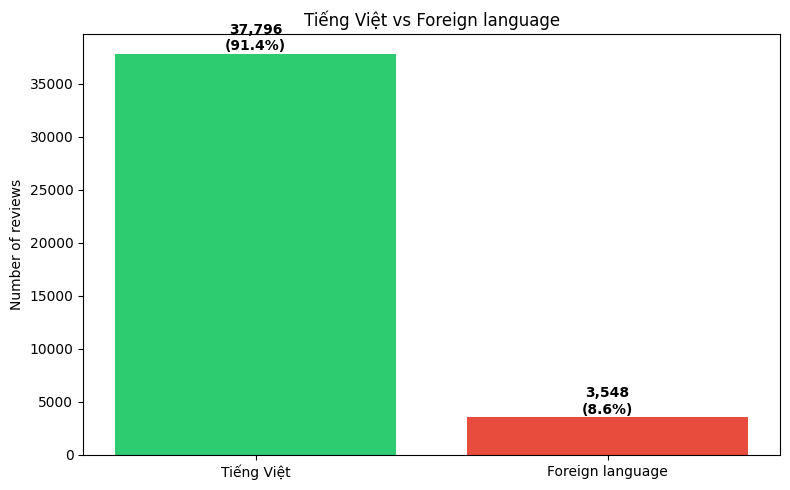

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
vi_count = (df['language'] == 'vi').sum()
non_vi_count = (df['language'] != 'vi').sum()
bars = ax.bar(['Tiếng Việt', 'Foreign language'], [vi_count, non_vi_count],
              color=['#2ecc71', '#e74c3c'])
ax.set_title('Tiếng Việt vs Foreign language')
ax.set_ylabel('Number of reviews')
for bar, val in zip(bars, [vi_count, non_vi_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Show some samples of non-Vietnamese reviews
non_vi = df[df['language'] != 'vi'].copy()
print(f'Total non-Vietnamese/unknown reviews: {len(non_vi):,}')
print()

for lang in non_vi['language'].unique()[:5]:
    print(f'--- {lang.upper()} ---')
    samples = non_vi[non_vi['language'] == lang]['review_text'].head(2)
    for s in samples:
        print(f'  {s[:120]}...' if len(str(s)) > 120 else f'  {s}')
    print()

Total non-Vietnamese/unknown reviews: 3,548

--- EN ---
  It's clean but you would feel that it's old. The bed is old too. I could feel the springs inside the mattress. The room ...
  Good location

--- UNKNOWN ---
  Ok
  Ổn

--- AF ---
  Good hotel
  Oke

--- PT ---
  Noi o tot
  Para o preço que é entrega o que é esperado. Não possui tanto conforto. Não tem elevador e sobe apenas de escadas. O qua...

--- JA ---
  一人には非常に満足
  バスタブとバルコニー付きの部屋にした場合、バスタブは半屋外にあるようです。したがって小さい蚊などは必然的に同居する事になるため殺虫剤スプレーが必要になります。



In [9]:
df_review_vi = df[df['language'] == 'vi'].copy()
df_review_non_vi = df[df['language'] != 'vi'].copy()

print(f"Total Vietnamese reviews: {len(df_review_vi):,}")
print(f"Total non-Vietnamese reviews: {len(df_review_non_vi):,}")

print('Description rating of Vietnamese reviews: ')
print(df_review_vi['rating'].describe())

print('Description rating of non-Vietnamese reviews: ')
print(df_review_non_vi['rating'].describe())

Total Vietnamese reviews: 37,796
Total non-Vietnamese reviews: 3,548
Description rating of Vietnamese reviews: 
count    37796.000000
mean         8.245370
std          2.114743
min          2.000000
25%          7.000000
50%          9.000000
75%         10.000000
max         10.000000
Name: rating, dtype: float64
Description rating of non-Vietnamese reviews: 
count    3548.000000
mean        8.914882
std         1.970482
min         2.000000
25%         8.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: rating, dtype: float64


## 5. Clean data

In [10]:
df_clean = df.copy()
initial_count = len(df_clean)
print(f'Total reviews: {initial_count:,}')

# Delete reviews with language non Vietnamese
df_clean = df_clean[df_clean['language'] == 'vi']
after_lang = len(df_clean)
print(f'After removing non-Vietnamese: {after_lang:,} (removed {initial_count - after_lang:,})')

# Delete duplicates based on review_id
df_clean = df_clean.drop_duplicates(subset='review_id', keep='first')
after_dedup = len(df_clean)
print(f'After deduplication: {after_dedup:,} (removed {after_lang - after_dedup:,})')

# Delete reviews with empty/NaN text
df_clean = df_clean[df_clean['review_text'].notna()]
df_clean = df_clean[df_clean['review_text'].astype(str).str.strip().str.len() > 0]
after_empty = len(df_clean)
print(f'After removing empty text: {after_empty:,} (removed {after_dedup - after_empty:,})')

# Delete reviews that are too short (< 5 characters) - likely gibberish or emoji only
df_clean['clean_text_len'] = df_clean['review_text'].astype(str).str.strip().str.len()
df_clean = df_clean[df_clean['clean_text_len'] >= 5]
after_short = len(df_clean)
print(f'After removing short text: {after_short:,} (removed {after_empty - after_short:,})')

# Remove the reviews that are gibberish (only contain random characters)
def is_gibberish(text):
    text = str(text).strip()
    if len(text) < 5:
        return True
    alpha_count = sum(c.isalpha() for c in text)
    if alpha_count / len(text) < 0.3:
        return True
    return False

gibberish_mask = df_clean['review_text'].apply(is_gibberish)
print(f'\nReview gibberish detect: {gibberish_mask.sum():,}')
if gibberish_mask.sum() > 0:
    print('Sample gibberish:')
    for text in df_clean[gibberish_mask]['review_text'].head(5):
        print(f'  "{text}"')

df_clean = df_clean[~gibberish_mask]
after_gibberish = len(df_clean)
print(f'After removing gibberish: {after_gibberish:,} (removed {after_short - after_gibberish:,})')

# Delete rating null
df_clean = df_clean[df_clean['rating'].notna()]
after_rating = len(df_clean)
print(f'After removing rating null: {after_rating:,} (removed {after_gibberish - after_rating:,})')

print(f'\n=========================================')
print(f'Total remaning reviews: {after_rating:,} / {initial_count:,} ({after_rating/initial_count*100:.1f}%)')

Total reviews: 41,344
After removing non-Vietnamese: 37,796 (removed 3,548)
After deduplication: 37,796 (removed 0)
After removing empty text: 37,796 (removed 0)
After removing short text: 37,328 (removed 468)

Review gibberish detect: 1
Sample gibberish:
  "hừm........."
After removing gibberish: 37,327 (removed 1)
After removing rating null: 37,327 (removed 0)

Total remaning reviews: 37,327 / 41,344 (90.3%)


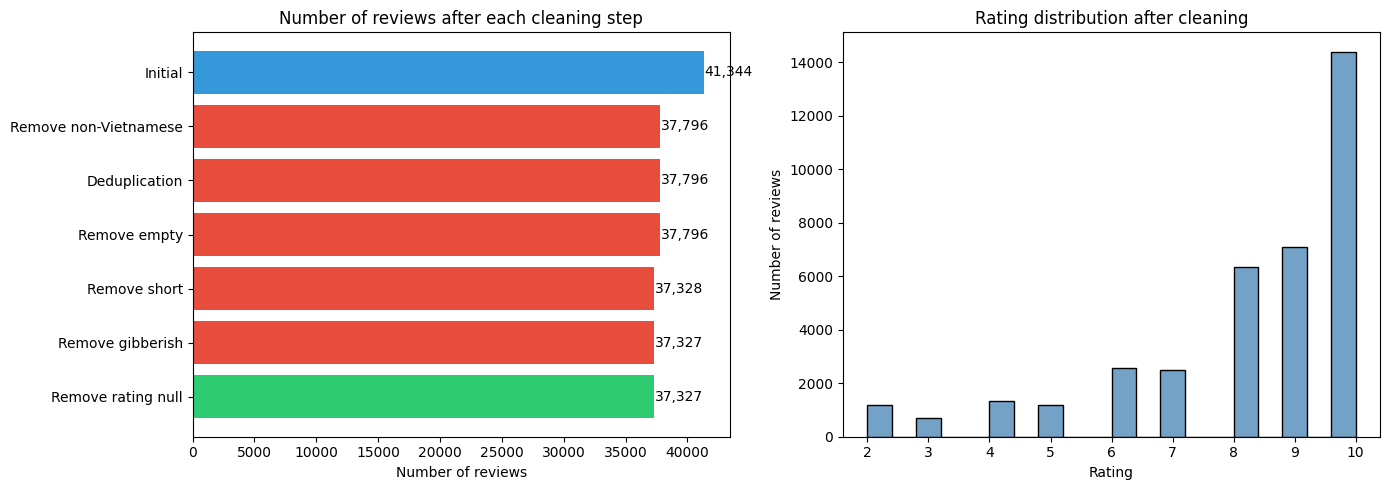

In [11]:
# Visualization trước/sau cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cleaning summary
stages = ['Initial', 'Remove non-Vietnamese', 'Deduplication', 'Remove empty', 'Remove short', 'Remove gibberish', 'Remove rating null']
# Thêm after_lang vào list counts
counts = [initial_count, after_lang, after_dedup, after_empty, after_short, after_gibberish, after_rating]
colors_bar = ['#3498db'] + ['#e74c3c'] * (len(counts) - 1)
colors_bar[-1] = '#2ecc71'

axes[0].barh(stages[::-1], counts[::-1], color=colors_bar[::-1])
axes[0].set_title('Number of reviews after each cleaning step')
axes[0].set_xlabel('Number of reviews')
for i, (stage, count) in enumerate(zip(stages[::-1], counts[::-1])):
    axes[0].text(count + 50, i, f'{count:,}', va='center')

# Rating distribution after cleaning
sns.histplot(df_clean['rating'].dropna(), bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Rating distribution after cleaning')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Number of reviews')

plt.tight_layout()
plt.show()


## 6. Save CSV

In [12]:
df_output = df_clean[['review_id', 'hotel_id', 'review_text', 'rating']].copy()

df_output = df_output.reset_index(drop=True)

df_output.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

print(f'Saved cleaned reviews to {OUTPUT_FILE}')
print(f'   Total reviews: {len(df_output):,}')
print(f'   Unique hotels: {df_output["hotel_id"].nunique():,}')
print(f'   Columns: {list(df_output.columns)}')

print()
df_output.head()

Saved cleaned reviews to reviews_cleaned.csv
   Total reviews: 37,327
   Unique hotels: 392
   Columns: ['review_id', 'hotel_id', 'review_text', 'rating']



,review_id,hotel_id,review_text,rating
0,1065527135,1001042,Sansan thật tuyệt vời và đó là nơi tôi luôn ch...,10.0
1,1042633845,1001042,Địa điểm tại đây khá thuận tiện cho khách du l...,8.0
2,970993281,1001042,Tôi rất thích khách sạn này. Nó nằm ở một con ...,10.0
3,889877242,1001042,trời ơi đi du lịch 1 mình từ lâu nhưng bà lễ t...,10.0
4,886199161,1001042,Tôi đã nhận được một số ưu đãi từ Agoda và có ...,10.0
